# Unfolding a Many-Body Spectrum


---

## Background

Every level-statistics diagnostic except the gap ratio compares the spacing between neighbouring levels with the *local* mean spacing. In a many-body spectrum that local mean varies by orders of magnitude across the band: the density of states is close to a Gaussian, exponentially dense in the middle and sparse at the edges. A histogram of raw spacings therefore measures the shape of the density of states, not the correlations between levels. Unfolding is the change of variable that removes the global density and leaves a sequence with unit mean spacing everywhere, so that the universal random-matrix laws can be seen.

Unfolding is also the step that most often goes wrong. This notebook carries it out end to end for the chaotic mixed-field Ising chain of Chapter 2, shows the symmetry trap that precedes it, and exhibits the two ways in which the smooth fit can fail.

## Mathematical background

Let $E_1\le E_2\le\dots\le E_D$ be the sorted levels of one symmetry sector and $N(E)=\#\{n : E_n\le E\}$ the integrated density of states (the *staircase*). Write it as a smooth part plus a fluctuating part, $N(E)=\bar N(E)+N_{\rm fl}(E)$. The unfolded levels are

$$\epsilon_n=\bar N(E_n),$$

so that $\epsilon_{n+1}-\epsilon_n\approx \bar N'(E_n)\,(E_{n+1}-E_n)$ is the raw spacing measured in units of the local mean spacing $1/\bar N'(E_n)=1/\bar\rho(E_n)$. By construction the unfolded spacings $s_n=\epsilon_{n+1}-\epsilon_n$ have unit mean, and for a chaotic Hamiltonian with time-reversal symmetry their distribution follows the Wigner surmise of the Gaussian orthogonal ensemble,

$$P(s)=\frac{\pi}{2}\,s\,e^{-\pi s^2/4},\qquad \langle s\rangle=1,\qquad \mathrm{Var}(s)=\frac{4}{\pi}-1\approx0.273 .$$

The gap ratio $r_n=\min(s_n,s_{n+1})/\max(s_n,s_{n+1})$ needs no unfolding because the local density cancels in the ratio; its large-$D$ GOE mean is $\langle r\rangle\approx0.531$ and its Poisson mean is $2\ln2-1\approx0.386$.

Two things can go wrong. If $\bar N$ is fit too rigidly (a low-degree polynomial that cannot follow the Gaussian bulk of the staircase), residual global density survives in $s_n$ and inflates its variance. If $\bar N$ is fit so flexibly that it follows individual steps of the staircase, the fit absorbs the fluctuations $N_{\rm fl}$ themselves, forces $s_n\approx1$ everywhere, and erases the very repulsion the diagnostic exists to see.

## Exercise

Consider the mixed-field Ising chain

$$\hat H=J\sum_{i}\hat Z_i\hat Z_{i+1}+h_x\sum_i\hat X_i+h_z\sum_i\hat Z_i,\qquad J=1,\; h_x=1.05,\; h_z=0.5,$$

with open boundaries and $N=12$ sites.

**(a) The obstacle.** Diagonalize the chain and form the raw nearest-neighbour spacings $s_n=E_{n+1}-E_n$. Show that their distribution is dominated by the varying density of states and does not resemble any universal law, and explain why comparing $s_n$ from the dense middle of the spectrum with $s_n$ from the sparse edges is meaningless.

**(b) Symmetry first.** The chain has a reflection symmetry $i\mapsto N-1-i$. Show that the gap ratio $\langle r\rangle$ computed on the full spectrum is close to $0.42$, below the GOE value, and that projecting onto one reflection-parity sector restores $\langle r\rangle\approx0.54$. Explain the contamination.

**(c) The unfolding map.** Within one sector build the integrated density $N(E)$, fit a smooth $\bar N(E)$ by a low-order polynomial over the central portion of the band, and define $\epsilon_n=\bar N(E_n)$. Verify that the mean spacing of the $\epsilon_n$ is unity.

**(d) The payoff and the two failure modes.** Show that the unfolded spacing distribution follows the Wigner surmise, with variance close to $4/\pi-1\approx0.273$. Then exhibit the two ways the fit can fail: a polynomial of degree $2$ that is too rigid, and a cubic spline with too little smoothing that chases the staircase. Explain why a low-order global polynomial sits safely between the two, and how over-fitting sets in as the degree of a global polynomial is raised.

## Toolbox

**Building the Hamiltonian.** With $D=2^N=4096$ the dense matrix is small enough to diagonalize directly. The $\hat Z\hat Z$ and $\hat Z$ terms are diagonal in the computational basis, and $\hat X_i$ flips bit $i$, so each row has $N$ off-diagonal entries equal to $h_x$.

**Reflection sectors.** The reflection $\hat P$ maps the basis state with bit string $b_0b_1\cdots b_{N-1}$ to the string read backwards. Pairs of distinct strings $\{b,\hat Pb\}$ give one symmetric and one antisymmetric combination; palindromic strings are symmetric on their own. The symmetric sector therefore has dimension $(2^N+2^{N/2})/2=2080$ and the antisymmetric sector $2016$.

**Fitting the staircase.** `numpy.polynomial.Chebyshev.fit` fits in an orthogonal basis on a rescaled domain and stays well conditioned up to very high degree, so it shows honestly how a global polynomial starts to over-fit as its degree grows; a monomial fit on the unscaled energy axis (`numpy.polyfit`) becomes ill conditioned beyond degree twenty or so, and from degree forty the solver truncates the smallest singular values, warns, and returns a curve of far lower effective degree than the nominal one. `scipy.interpolate.UnivariateSpline` with smoothing parameter $s$ is the flexible local fit whose over-fit is abrupt.

## Solution

### Part (a): the raw spacings measure the density of states, not the correlations

In [1]:
import numpy as np
import warnings
import matplotlib.pyplot as plt
from numpy.polynomial import Chebyshev
from scipy.interpolate import UnivariateSpline
warnings.filterwarnings("ignore", category=np.exceptions.RankWarning)   # only the deliberate monomial fit below triggers this
warnings.filterwarnings("ignore", category=RuntimeWarning)              # overflow inside that same rank-deficient monomial fit

N, J, hx, hz = 12, 1.0, 1.05, 0.5
D = 2**N
idx = np.arange(D)
bits = (idx[:, None] >> np.arange(N)[None, :]) & 1        # bit j of basis state = site j
z = 1 - 2*bits                                              # Z eigenvalues (+1 for bit 0)

H = np.diag(J*np.sum(z[:, :-1]*z[:, 1:], axis=1) + hz*np.sum(z, axis=1)).astype(float)
for j in range(N):
    H[idx, idx ^ (1 << j)] += hx                            # X_j flips bit j

E_full = np.linalg.eigvalsh(H)
s_raw = np.diff(E_full)
print(f"D = {D} levels, band from {E_full[0]:.2f} to {E_full[-1]:.2f}")
print(f"raw spacings: mean {s_raw.mean():.4f}, min {s_raw.min():.2e}, max {s_raw.max():.3f}")
print(f"raw spacing variance / mean^2 = {s_raw.var()/s_raw.mean()**2:.1f}   (Wigner surmise: 0.273)")

D = 4096 levels, band from -15.71 to 19.95
raw spacings: mean 0.0087, min 1.53e-06, max 2.920
raw spacing variance / mean^2 = 35.8   (Wigner surmise: 0.273)


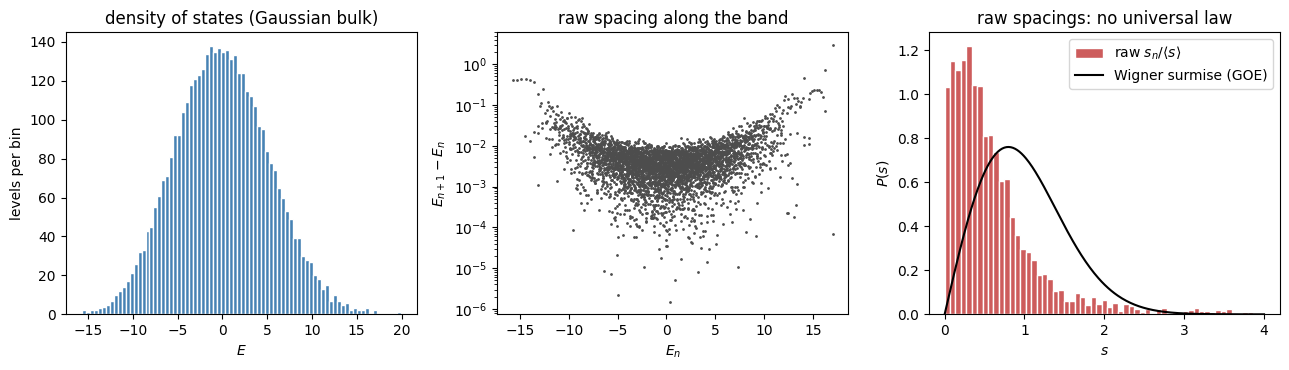

In [2]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
ax[0].hist(E_full, bins=80, color="steelblue", edgecolor="white")
ax[0].set_xlabel("$E$"); ax[0].set_ylabel("levels per bin"); ax[0].set_title("density of states (Gaussian bulk)")
ax[1].semilogy(E_full[:-1], s_raw, ".", ms=2, color="0.3")
ax[1].set_xlabel("$E_n$"); ax[1].set_ylabel("$E_{n+1}-E_n$"); ax[1].set_title("raw spacing along the band")
ax[2].hist(s_raw/s_raw.mean(), bins=np.linspace(0, 4, 60), density=True, color="indianred", edgecolor="white",
           label="raw $s_n/\\langle s\\rangle$")
sg = np.linspace(0, 4, 300)
ax[2].plot(sg, np.pi/2*sg*np.exp(-np.pi*sg**2/4), "k-", lw=1.5, label="Wigner surmise (GOE)")
ax[2].set_xlabel("$s$"); ax[2].set_ylabel("$P(s)$"); ax[2].set_title("raw spacings: no universal law"); ax[2].legend()
plt.tight_layout(); plt.show()

The middle panel is the whole story: the spacing varies by four orders of magnitude across the band, tracking the inverse of the density of states in the left panel. A raw spacing of $10^{-3}$ from the centre and one of $10^{-1}$ from an edge may both be "typical" relative to their local mean, so pooling them into one histogram (right panel) mixes incomparable quantities. The pooled histogram is a spike at zero with a long tail, nothing like the Wigner surmise.

### Part (b): resolve the reflection symmetry before anything else

In [3]:
def gap_ratio(E):
    s = np.diff(E)
    r = np.minimum(s[:-1], s[1:]) / np.maximum(s[:-1], s[1:])
    return r.mean()

# reflection i -> N-1-i acting on bit strings
refl = np.zeros(D, dtype=int)
for j in range(N):
    refl |= ((idx >> j) & 1) << (N - 1 - j)

sym, asym, seen = [], [], np.zeros(D, bool)
for i in range(D):
    if seen[i]:
        continue
    j = refl[i]; seen[i] = seen[j] = True
    v = np.zeros(D)
    if i == j:                       # palindrome: symmetric on its own
        v[i] = 1.0; sym.append(v)
    else:
        v[i] = v[j] = 1/np.sqrt(2); sym.append(v)
        w = np.zeros(D); w[i] = 1/np.sqrt(2); w[j] = -1/np.sqrt(2); asym.append(w)
B_plus, B_minus = np.array(sym).T, np.array(asym).T
E_plus  = np.linalg.eigvalsh(B_plus.T  @ H @ B_plus)
E_minus = np.linalg.eigvalsh(B_minus.T @ H @ B_minus)

print(f"sector dimensions: +1 -> {len(E_plus)},  -1 -> {len(E_minus)}")
print(f"<r> full spectrum   = {gap_ratio(E_full):.3f}   (Poisson 0.386, GOE 0.531)")
print(f"<r> +1 sector       = {gap_ratio(E_plus):.3f}")
print(f"<r> -1 sector       = {gap_ratio(E_minus):.3f}")

sector dimensions: +1 -> 2080,  -1 -> 2016
<r> full spectrum   = 0.420   (Poisson 0.386, GOE 0.531)
<r> +1 sector       = 0.543
<r> -1 sector       = 0.521


The full spectrum interleaves two statistically independent sequences. A level of the $+1$ sector feels no repulsion from a level of the $-1$ sector, so near-degeneracies between the two sectors are as common as for uncorrelated levels; this superposition pulls $\langle r\rangle$ down from the GOE value toward the Poisson value (Rosenzweig and Porter, 1960). Within one sector the sequence is a single correlated one and the gap ratio returns to the GOE value, up to a scatter of order $0.01$ for a sample of about two thousand levels. All further steps use the $+1$ sector.

### Part (c): the unfolding map

In [4]:
def central(E, keep=0.8):
    # keep the central fraction of the sorted sector spectrum; return energies and staircase values N(E_n) = n
    n = len(E); lo = int(round(n*(1-keep)/2)); hi = n - lo
    return E[lo:hi], np.arange(lo+1, hi+1, dtype=float)

def unfold_poly(E, deg, keep=0.8):
    Ec, Nc = central(E, keep)
    Nbar = Chebyshev.fit(Ec, Nc, deg)          # orthogonal basis on a rescaled domain: well conditioned at any degree
    return Nbar(Ec), Nbar, Ec, Nc

eps, Nbar, Ec, Nc = unfold_poly(E_plus, deg=9)
s_unf = np.diff(eps)
print(f"levels kept: {len(Ec)} of {len(E_plus)} (central 80%)")
print(f"mean unfolded spacing = {s_unf.mean():.4f}   (must be 1)")
print(f"variance of unfolded spacing = {s_unf.var():.4f}   (Wigner surmise 4/pi - 1 = {4/np.pi-1:.4f}, exact GOE 0.286)")

levels kept: 1664 of 2080 (central 80%)
mean unfolded spacing = 1.0012   (must be 1)
variance of unfolded spacing = 0.2753   (Wigner surmise 4/pi - 1 = 0.2732, exact GOE 0.286)


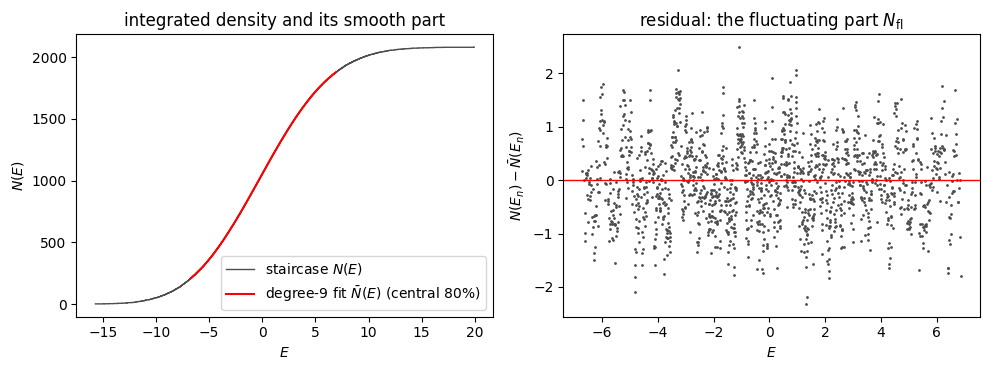

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
ax[0].step(E_plus, np.arange(1, len(E_plus)+1), where="post", color="0.3", lw=1, label="staircase $N(E)$")
Eg = np.linspace(Ec[0], Ec[-1], 400)
ax[0].plot(Eg, Nbar(Eg), "r-", lw=1.5, label="degree-9 fit $\\bar N(E)$ (central 80%)")
ax[0].set_xlabel("$E$"); ax[0].set_ylabel("$N(E)$"); ax[0].legend(); ax[0].set_title("integrated density and its smooth part")
ax[1].plot(Ec, Nc - Nbar(Ec), ".", ms=2, color="0.3")
ax[1].axhline(0, color="r", lw=1)
ax[1].set_xlabel("$E$"); ax[1].set_ylabel("$N(E_n)-\\bar N(E_n)$"); ax[1].set_title("residual: the fluctuating part $N_{\\rm fl}$")
plt.tight_layout(); plt.show()

The residual in the right panel is what unfolding is supposed to leave behind: a fluctuating part of order one with no visible trend. Its size is what spectral rigidity measures (the number variance of Chapter 2 grows only logarithmically with the window), and it is exactly the part a good fit must *not* absorb.

### Part (d): the payoff, and the two failure modes

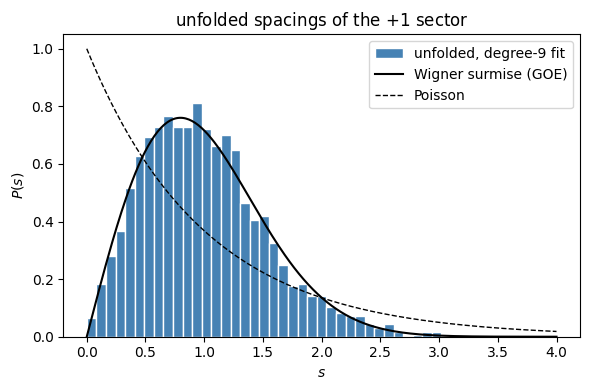

Chebyshev degree   Var(s)   (surmise 0.273)
         2          0.358
         5          0.275
         9          0.275
        15          0.275
        30          0.277
        50          0.273


       100          0.269


       300          0.250


       800          0.183

nominal monomial degree (np.polyfit)   Var(s)   singular values kept by the solver
         9                            0.275        10 of 10
        30                            0.277        31 of 31
        40                            0.273        37 of 41
       100                            0.272        48 of 101
       300                            0.271        54 of 301


In [6]:
def var_unit_mean(s):
    # variance of the spacings after normalising them to unit mean (removes any residual scale error)
    s = s / s.mean()
    return s.var()

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(s_unf, bins=np.linspace(0, 4, 50), density=True, color="steelblue", edgecolor="white", label="unfolded, degree-9 fit")
ax.plot(sg, np.pi/2*sg*np.exp(-np.pi*sg**2/4), "k-", lw=1.5, label="Wigner surmise (GOE)")
ax.plot(sg, np.exp(-sg), "k--", lw=1, label="Poisson")
ax.set_xlabel("$s$"); ax.set_ylabel("$P(s)$"); ax.legend(); ax.set_title("unfolded spacings of the $+1$ sector")
plt.tight_layout(); plt.show()

print("Chebyshev degree   Var(s)   (surmise 0.273)")
for deg in [2, 5, 9, 15, 30, 50, 100, 300, 800]:
    e, *_ = unfold_poly(E_plus, deg)
    print(f"      {deg:4d}          {var_unit_mean(np.diff(e)):.3f}")

# the same nominal degrees with monomials on the unscaled energy axis: from degree forty the solver truncates
# the fit, so the variance appears not to move; the returned curve has effective degree of order fifty
print()
print("nominal monomial degree (np.polyfit)   Var(s)   singular values kept by the solver")
for deg in [9, 30, 40, 100, 300]:
    c, _, rk, _, _ = np.polyfit(Ec, Nc, deg, full=True)
    print(f"      {deg:4d}                            {var_unit_mean(np.diff(np.polyval(c, Ec))):.3f}        {rk} of {deg + 1}")

spline smoothing s     Var(s)
          1000         0.2744


           100         0.1674


            10         0.0204


             1         0.0021
             0         0.0000


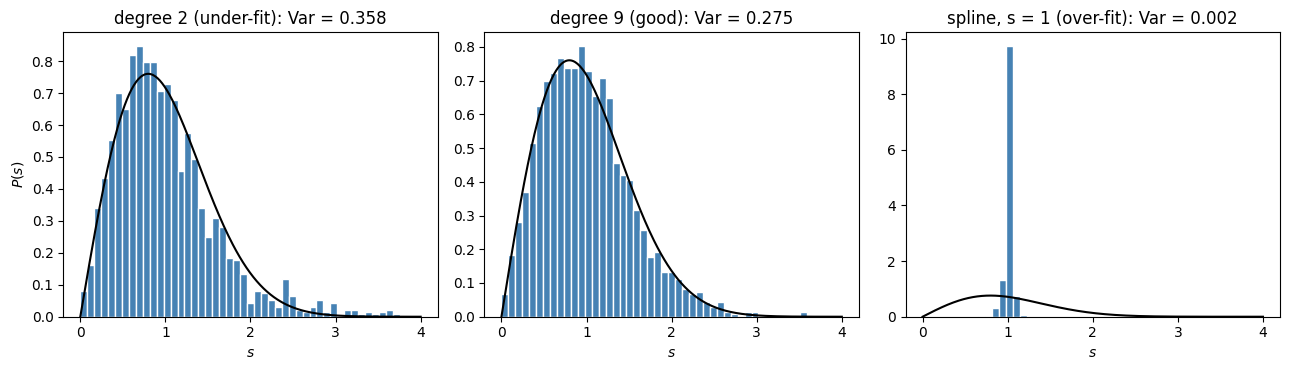

In [7]:
# the abrupt over-fit: a LOCAL fit (cubic smoothing spline) that follows the staircase step by step
Ec, Nc = central(E_plus, 0.8)
print("spline smoothing s     Var(s)")
for sm in [1e3, 1e2, 10, 1, 0]:
    spl = UnivariateSpline(Ec, Nc, k=3, s=sm)
    print(f"      {sm:8.0f}         {var_unit_mean(np.diff(spl(Ec))):.4f}")

fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
for a, (label, e) in zip(ax, [("degree 2 (under-fit)", unfold_poly(E_plus, 2)[0]),
                               ("degree 9 (good)", unfold_poly(E_plus, 9)[0]),
                               ("spline, s = 1 (over-fit)", UnivariateSpline(Ec, Nc, k=3, s=1)(Ec))]):
    s = np.diff(e); s = s/s.mean()
    a.hist(s, bins=np.linspace(0, 4, 50), density=True, color="steelblue", edgecolor="white")
    a.plot(sg, np.pi/2*sg*np.exp(-np.pi*sg**2/4), "k-", lw=1.5)
    a.set_title(f"{label}: Var = {s.var():.3f}"); a.set_xlabel("$s$")
ax[0].set_ylabel("$P(s)$")
plt.tight_layout(); plt.show()

**Under-fitting.** A quadratic cannot follow the Gaussian bulk of the staircase. The residual $N-\bar N$ then still contains a slow trend, the unfolded spacings inherit a slowly varying scale, and the variance is inflated to about $0.36$. The histogram is a Wigner-like shape smeared by that residual density.

**Over-fitting sets in gradually with the degree of a global polynomial.** A polynomial of degree $p$ fitted to $n$ levels can bend on the scale of $n/p$ spacings, so once $n/p$ drops to a few tens of spacings, where the number variance is already of order one, the fit starts to absorb the fluctuations it should leave alone. On the $1664$ central levels a Chebyshev fit gives $\mathrm{Var}(s)=0.275,\,0.273,\,0.269,\,0.250,\,0.18$ at degree $9,\,50,\,100,\,300,\,800$: a slow drift, not a cliff. The monomial fit on the unscaled energy axis seems immune, returning about $0.27$ even at nominal degree $300$, but only because the system is ill conditioned beyond degree twenty and from degree forty the solver truncates it, keeping about fifty singular values at nominal degree $300$ and warning that the fit is poorly conditioned. The value $0.271$ is indistinguishable at this sample size (standard error about $0.01$) from the well-conditioned fits of degree nine to one hundred, so the apparent robustness is a property of the truncated solver, not of the polynomial.

**Over-fitting is abrupt with a local fit.** A cubic smoothing spline with the smoothing turned down follows the staircase level by level, so $\epsilon_{n+1}-\epsilon_n\approx1$ for every $n$, and the variance collapses toward zero (about $0.002$ at $s=1$, exactly $0$ for the interpolating spline). The histogram becomes a spike at $s=1$: all correlations, including the repulsion the diagnostic exists to see, have been absorbed into $\bar N$.

**The safe recipe** is therefore a global polynomial of degree between about five and fifteen, fitted in a rescaled or orthogonal basis to the central part of the band, with the check that the variance does not move when the degree is varied within that range.


---
## Adversarial check — every quoted number, machine-verified

In [8]:
checks = []
r_full, r_plus, r_minus = gap_ratio(E_full), gap_ratio(E_plus), gap_ratio(E_minus)
checks.append(("sector dimensions 2080 / 2016", (len(E_plus), len(E_minus)) == (2080, 2016)))
checks.append((f"full-spectrum <r> = {r_full:.3f} is close to 0.42", abs(r_full - 0.42) < 0.01))
checks.append((f"+1 sector <r> = {r_plus:.3f} is close to 0.54", abs(r_plus - 0.54) < 0.01))
checks.append((f"-1 sector <r> = {r_minus:.3f} is close to 0.52", abs(r_minus - 0.52) < 0.01))
e9, *_ = unfold_poly(E_plus, 9)
checks.append((f"degree-9 unfolding: mean spacing = {np.diff(e9).mean():.4f} (unity)", abs(np.diff(e9).mean() - 1) < 5e-3))
checks.append((f"degree-9 unfolding: Var(s) = {var_unit_mean(np.diff(e9)):.3f} (0.275)", abs(var_unit_mean(np.diff(e9)) - 0.275) < 0.01))
e2, *_ = unfold_poly(E_plus, 2)
checks.append((f"degree-2 under-fit: Var(s) = {var_unit_mean(np.diff(e2)):.3f} (0.36)", abs(var_unit_mean(np.diff(e2)) - 0.36) < 0.02))
e300, *_ = unfold_poly(E_plus, 300)
checks.append((f"degree-300 Chebyshev fit: Var(s) = {var_unit_mean(np.diff(e300)):.3f} (0.250, gradual over-fit)", abs(var_unit_mean(np.diff(e300)) - 0.250) < 0.01))
e800, *_ = unfold_poly(E_plus, 800)
checks.append((f"degree-800 Chebyshev fit: Var(s) = {var_unit_mean(np.diff(e800)):.3f} (0.18)", abs(var_unit_mean(np.diff(e800)) - 0.18) < 0.02))
c300, _, rank300, _, _ = np.polyfit(Ec, Nc, 300, full=True)
checks.append((f"nominal degree-300 monomial fit: Var(s) = {var_unit_mean(np.diff(np.polyval(c300, Ec))):.3f}, solver keeps {rank300} of 301 singular values (truncated fit)", rank300 < 100))
spl = UnivariateSpline(Ec, Nc, k=3, s=1)
checks.append((f"spline s=1 over-fit: Var(s) = {var_unit_mean(np.diff(spl(Ec))):.4f} (0.002)", var_unit_mean(np.diff(spl(Ec))) < 0.005))
checks.append((f"levels in the central 80% of the +1 sector = {len(Ec)} (1664)", len(Ec) == 1664))
checks.append((f"Wigner-surmise variance 4/pi - 1 = {4/np.pi-1:.4f}", abs(4/np.pi - 1 - 0.2732) < 1e-3))

for name, ok in checks:
    print(("PASS " if ok else "FAIL ") + name)
assert all(ok for _, ok in checks)

PASS sector dimensions 2080 / 2016
PASS full-spectrum <r> = 0.420 is close to 0.42
PASS +1 sector <r> = 0.543 is close to 0.54
PASS -1 sector <r> = 0.521 is close to 0.52
PASS degree-9 unfolding: mean spacing = 1.0012 (unity)
PASS degree-9 unfolding: Var(s) = 0.275 (0.275)
PASS degree-2 under-fit: Var(s) = 0.358 (0.36)
PASS degree-300 Chebyshev fit: Var(s) = 0.250 (0.250, gradual over-fit)
PASS degree-800 Chebyshev fit: Var(s) = 0.183 (0.18)
PASS nominal degree-300 monomial fit: Var(s) = 0.271, solver keeps 54 of 301 singular values (truncated fit)
PASS spline s=1 over-fit: Var(s) = 0.0021 (0.002)
PASS levels in the central 80% of the +1 sector = 1664 (1664)
PASS Wigner-surmise variance 4/pi - 1 = 0.2732


## Takeaway

Unfolding removes the global density of states by mapping each level to the smooth staircase value $\epsilon_n=\bar N(E_n)$, after which spacings from every part of the band are comparable and the Wigner surmise appears. Two errors dominate practice. Forgetting to resolve a symmetry superposes independent sequences and pulls the statistics toward Poisson; here the reflection symmetry alone drags $\langle r\rangle$ from $0.54$ to $0.42$. Fitting the staircase too rigidly leaves residual density and inflates the spacing variance; raising the degree of a global polynomial over-fits gradually, and a local fit that follows individual levels erases the correlations abruptly. A monomial fit at high nominal degree only looks harmless because the solver truncates it to an effective degree of order fifty.

## Connections

- The gap ratio used in part (b) is the unfolding-free diagnostic of Chapter 2; the Wigner surmise it is compared with is derived in [the $2\times2$ GOE notebook](solution_ch2_goe_spacing.ipynb).
- The residual $N_{\rm fl}$ of part (c) is the object whose variance over a window is the number variance $\Sigma^2$, the static measure of spectral rigidity whose dynamical face is the ramp of the spectral form factor (Chapter 4).
- The same mixed-field Ising chain, in the same reflection sector, is the many-body example whose spectral form factor is computed in Chapter 4.

## References

- Bohigas, Giannoni and Schmit, *Characterization of chaotic quantum spectra and universality of level fluctuation laws*, Phys. Rev. Lett. 52, 1 (1984).
- Rosenzweig and Porter, *"Repulsion of energy levels" in complex atomic spectra*, Phys. Rev. 120, 1698 (1960).
- Atas, Bogomolny, Giraud and Roux, *Distribution of the ratio of consecutive level spacings in random matrix ensembles*, Phys. Rev. Lett. 110, 084101 (2013).
- Haake, *Quantum Signatures of Chaos*, Springer (2010).